Gradient Boosting Models:
* Gradient Boosting Classifier (xgboost, lightgbm)
* Use StratifiedKFold for better train/test split
* Confirm results using confusion matrix, recall, precision, F1 scores

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report
from sklearn.preprocessing import OrdinalEncoder

In [81]:
# use cvd risk level not cvd risk score
# blood pressure categories found from https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings
# remove systolic, diastolic, and blood pressure, just keep blood pressure category (determined by systolic over diastolic values)

df = pd.read_csv('cvd_dataset.csv')
df_edited = df.drop(columns=['Blood Pressure (mmHg)','Systolic BP','Diastolic BP'])

# ordinal encoding categories
sex_categories = ['F','M'] 
physical_activity_categories = ['Low','Moderate','High']
blood_pressure_categories = ['Normal','Elevated','Hypertension Stage 1','Hypertension Stage 2']
# smoking, diabetes, family history all Y/N (0,1)
yn_categories = ['Y','N']
# cvd risk levels (0,1,2)
risk_categories = ['LOW','INTERMEDIARY','HIGH']

encoder = OrdinalEncoder(categories=[sex_categories, physical_activity_categories, blood_pressure_categories, yn_categories, yn_categories, yn_categories,risk_categories])
df_edited[['Sex','Physical Activity Level','Blood Pressure Category','Smoking Status','Diabetes Status','Family History of CVD','CVD Risk Level']] = encoder.fit_transform(df_edited[['Sex','Physical Activity Level','Blood Pressure Category','Smoking Status','Diabetes Status','Family History of CVD','CVD Risk Level']])

X = df_edited.drop(columns=['CVD Risk Level','CVD Risk Score'])
y = df_edited['CVD Risk Level']

1 :  0.6774193548387096
2 :  0.6129032258064516
3 :  0.6774193548387096
4 :  0.7741935483870968
5 :  0.6129032258064516
6 :  0.7741935483870968
7 :  0.7096774193548387
8 :  0.7096774193548387
9 :  0.6774193548387096
10 :  0.6451612903225806
11 :  0.6451612903225806
12 :  0.6129032258064516
13 :  0.7419354838709677
14 :  0.5806451612903226
15 :  0.5483870967741935
16 :  0.5483870967741935
17 :  0.6451612903225806
18 :  0.5806451612903226
19 :  0.6129032258064516
20 :  0.7741935483870968
21 :  0.7096774193548387
22 :  0.6774193548387096
23 :  0.5161290322580645
24 :  0.7096774193548387
25 :  0.7096774193548387
26 :  0.6129032258064516
27 :  0.6774193548387096
28 :  0.6129032258064516
29 :  0.6774193548387096
30 :  0.6666666666666666
31 :  0.8
32 :  0.6
33 :  0.5666666666666667
34 :  0.7666666666666667
35 :  0.6
36 :  0.7666666666666667
37 :  0.5666666666666667
38 :  0.7666666666666667
39 :  0.6333333333333333
40 :  0.8333333333333334
41 :  0.6
42 :  0.6
43 :  0.6666666666666666
44 :  0.6

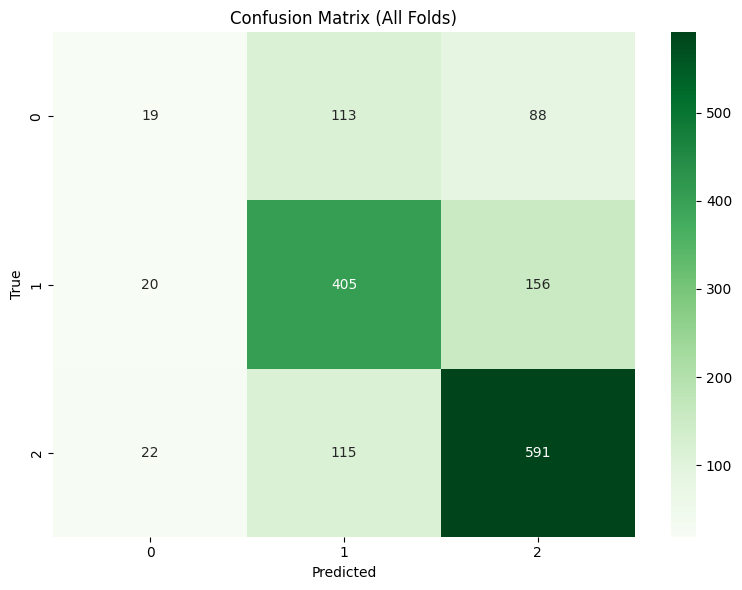

Cross-Validation Results (Accuracy):
  Fold 1: 67.74%
  Fold 2: 61.29%
  Fold 3: 67.74%
  Fold 4: 77.42%
  Fold 5: 61.29%
  Fold 6: 77.42%
  Fold 7: 70.97%
  Fold 8: 70.97%
  Fold 9: 67.74%
  Fold 10: 64.52%
  Fold 11: 64.52%
  Fold 12: 61.29%
  Fold 13: 74.19%
  Fold 14: 58.06%
  Fold 15: 54.84%
  Fold 16: 54.84%
  Fold 17: 64.52%
  Fold 18: 58.06%
  Fold 19: 61.29%
  Fold 20: 77.42%
  Fold 21: 70.97%
  Fold 22: 67.74%
  Fold 23: 51.61%
  Fold 24: 70.97%
  Fold 25: 70.97%
  Fold 26: 61.29%
  Fold 27: 67.74%
  Fold 28: 61.29%
  Fold 29: 67.74%
  Fold 30: 66.67%
  Fold 31: 80.00%
  Fold 32: 60.00%
  Fold 33: 56.67%
  Fold 34: 76.67%
  Fold 35: 60.00%
  Fold 36: 76.67%
  Fold 37: 56.67%
  Fold 38: 76.67%
  Fold 39: 63.33%
  Fold 40: 83.33%
  Fold 41: 60.00%
  Fold 42: 60.00%
  Fold 43: 66.67%
  Fold 44: 63.33%
  Fold 45: 66.67%
  Fold 46: 53.33%
  Fold 47: 66.67%
  Fold 48: 66.67%
  Fold 49: 76.67%
  Fold 50: 76.67%


In [82]:
# https://www.geeksforgeeks.org/machine-learning/stratified-k-fold-cross-validation/
# gradient boosting machines
# builds decision trees in a serial fashion -- each tree is fit to the gradient of the loss function of the current stage's ensemble

kf = StratifiedKFold(n_splits=50,shuffle=True,random_state=42)
metrics = []
all_y_true = []
all_y_pred = []

cust_params = {'objective':'multiclass',
          'metric':'multi_logloss',
          'boosting_type':'gbdt',
          'num_leaves':31,
          'max_depth':-1, # higher depth leads to overfitting
          'n_estimators':100,
          'learning_rate':0.03,
          'min_data_in_leaf':2,
          'random_state':0,
          'num_class':3,
          'feature_fraction':1,
          'bagging_fraction':1,
          'verbosity':-1}

fold_num = 1
for train_index, test_index in kf.split(X,y): # splits dataset into stratified train-test indices
    X_train, X_test = X.iloc[train_index], X.iloc[test_index] # features
    y_train, y_test = y[train_index], y[test_index] # labels
    
    # creation of lightgbm datasets
    train_lgb_data = lgb.Dataset(X_train, label=y_train)
    test_lgb_data = lgb.Dataset(X_test, label=y_test)

    lgb_model = lgb.train(params=cust_params, train_set=train_lgb_data, num_boost_round=100,valid_sets=test_lgb_data)
    
    y_pred = lgb_model.predict(X_test)
    y_pred_labels = np.argmax(y_pred, axis=1)

    accuracy = accuracy_score(y_test, y_pred_labels)
    print(fold_num, ': ',accuracy)
    fold_num += 1
    metrics.append(accuracy)
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred_labels)

print(classification_report(all_y_true, all_y_pred, target_names=encoder.categories_[6]))
cm = confusion_matrix(all_y_true, all_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (All Folds)')
plt.tight_layout()
plt.show()
# # cross_val_results = cross_val_score(model, X, y_encoded, cv=kf, scoring ='accuracy')

print("Cross-Validation Results (Accuracy):")
for i, result in enumerate(metrics, 1):
    print(f"  Fold {i}: {result * 100:.2f}%")

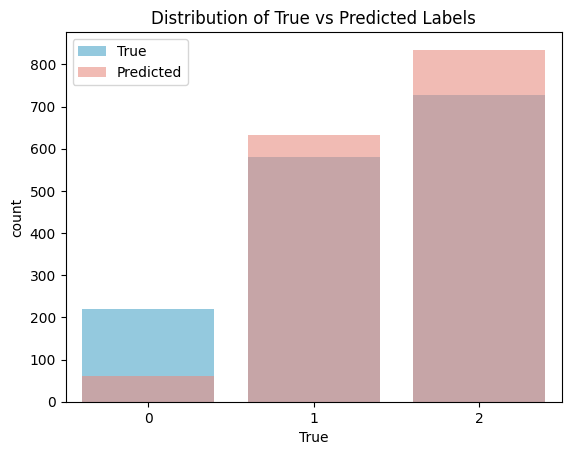

In [74]:
# graph visualization
def graph_vis(all_y_true,all_y_pred):
    cm = confusion_matrix(all_y_true, all_y_pred)
    df_preds = pd.DataFrame({"True": [int(x) for x in all_y_true],
                            "Predicted": all_y_pred})

    sns.countplot(x="True", data=df_preds, label="True", color="skyblue")
    sns.countplot(x="Predicted", data=df_preds, label="Predicted", color="salmon", alpha=0.6)
    plt.legend()
    plt.title("Distribution of True vs Predicted Labels")
    plt.show()

graph_vis(all_y_true,all_y_pred)

XGBoost Model

1 :  0.625
2 :  0.75
3 :  0.4375
4 :  0.625
5 :  0.625
6 :  0.8125
7 :  0.6875
8 :  0.5
9 :  0.5625
10 :  0.625
11 :  0.875
12 :  0.6875
13 :  0.5
14 :  0.6875
15 :  0.5625
16 :  0.5
17 :  0.625
18 :  0.625
19 :  0.75
20 :  0.625
21 :  0.5625
22 :  0.5625
23 :  0.5625
24 :  0.7333333333333333
25 :  0.6
26 :  0.8
27 :  0.6
28 :  0.6
29 :  0.6666666666666666
30 :  0.5333333333333333
31 :  0.8666666666666667
32 :  0.6
33 :  0.8666666666666667
34 :  0.8
35 :  0.8
36 :  0.6666666666666666
37 :  0.5333333333333333
38 :  0.7333333333333333
39 :  0.8666666666666667
40 :  0.6
41 :  0.6666666666666666
42 :  0.7333333333333333
43 :  0.6
44 :  0.8666666666666667
45 :  0.6
46 :  0.6
47 :  0.7333333333333333
48 :  0.5333333333333333
49 :  0.6666666666666666
50 :  0.5333333333333333
              precision    recall  f1-score   support

         LOW       0.28      0.23      0.25       106
INTERMEDIARY       0.65      0.66      0.66       288
        HIGH       0.74      0.77      0.75       379

   

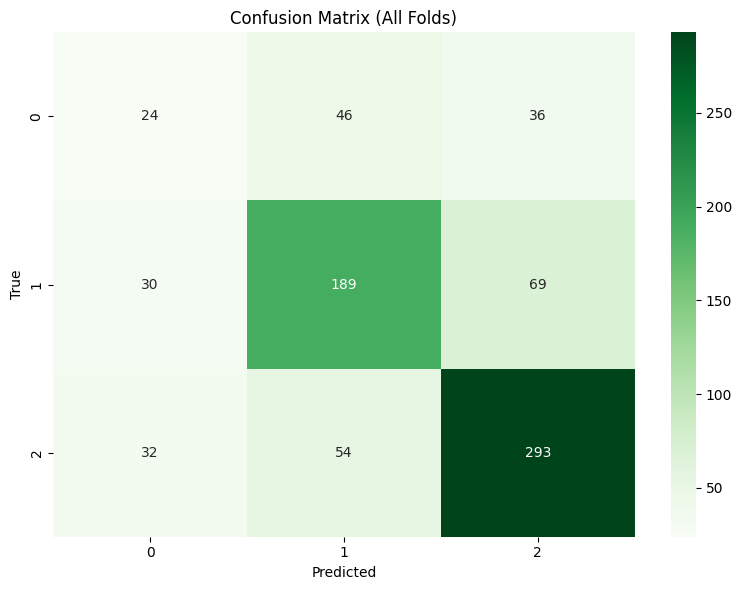

Cross-Validation Results (Accuracy):
  Fold 1: 62.50%
  Fold 2: 75.00%
  Fold 3: 43.75%
  Fold 4: 62.50%
  Fold 5: 62.50%
  Fold 6: 81.25%
  Fold 7: 68.75%
  Fold 8: 50.00%
  Fold 9: 56.25%
  Fold 10: 62.50%
  Fold 11: 87.50%
  Fold 12: 68.75%
  Fold 13: 50.00%
  Fold 14: 68.75%
  Fold 15: 56.25%
  Fold 16: 50.00%
  Fold 17: 62.50%
  Fold 18: 62.50%
  Fold 19: 75.00%
  Fold 20: 62.50%
  Fold 21: 56.25%
  Fold 22: 56.25%
  Fold 23: 56.25%
  Fold 24: 73.33%
  Fold 25: 60.00%
  Fold 26: 80.00%
  Fold 27: 60.00%
  Fold 28: 60.00%
  Fold 29: 66.67%
  Fold 30: 53.33%
  Fold 31: 86.67%
  Fold 32: 60.00%
  Fold 33: 86.67%
  Fold 34: 80.00%
  Fold 35: 80.00%
  Fold 36: 66.67%
  Fold 37: 53.33%
  Fold 38: 73.33%
  Fold 39: 86.67%
  Fold 40: 60.00%
  Fold 41: 66.67%
  Fold 42: 73.33%
  Fold 43: 60.00%
  Fold 44: 86.67%
  Fold 45: 60.00%
  Fold 46: 60.00%
  Fold 47: 73.33%
  Fold 48: 53.33%
  Fold 49: 66.67%
  Fold 50: 53.33%


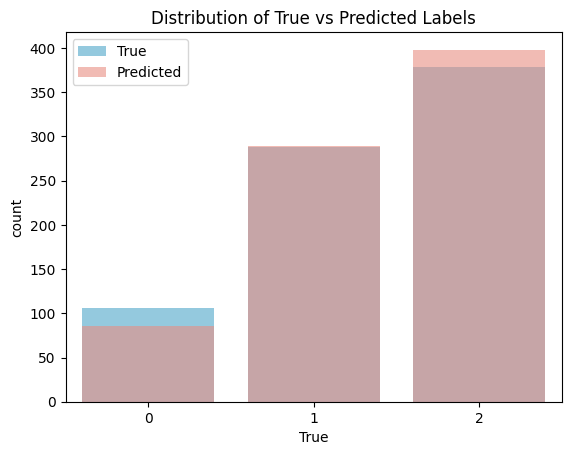

In [80]:
xgb_model = xgb.XGBClassifier(objective='multi:softprob',num_class=3,eval_metric='mlogloss')

kf = StratifiedKFold(n_splits=50,shuffle=True,random_state=42)
metrics = []
xgb_y_true = []
xgb_y_pred = []

fold_num = 1
for train_index, test_index in kf.split(X,y): # splits dataset into stratified train-test indices
    X_train, X_test = X.iloc[train_index], X.iloc[test_index] # features
    y_train, y_test = y[train_index], y[test_index] # labels
    
    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)
    # y_pred_labels = np.argmax(y_pred, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    print(fold_num, ': ',accuracy)
    fold_num += 1
    metrics.append(accuracy)
    xgb_y_true.extend(y_test)
    xgb_y_pred.extend(y_pred)

print(classification_report(xgb_y_true, xgb_y_pred, target_names=encoder.categories_[6]))
cm = confusion_matrix(xgb_y_true, xgb_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (All Folds)')
plt.tight_layout()
plt.show()

print("Cross-Validation Results (Accuracy):")
for i, result in enumerate(metrics, 1):
    print(f"  Fold {i}: {result * 100:.2f}%")

graph_vis(xgb_y_true,xgb_y_pred)